# 과제6

In [2]:
import os
import pydicom

def read_dicom_files(dicom_path):
    dicom_files = {}
    for fname in os.listdir(dicom_path):
        if fname.endswith('.dcm'):
            filepath = os.path.join(dicom_path, fname)
            ds = pydicom.dcmread(filepath)

            slice_idx = int(os.path.splitext(fname)[0])  # 파일명에서 인덱스 추출
            dicom_files[slice_idx] = ds
    return dicom_files

In [3]:
import pydicom

dicom_path = '/Users/g.j.kim/Downloads/Task6Data/blind'
task6_dicom_files = read_dicom_files('/Users/g.j.kim/Downloads/Task6Data/blind')

In [4]:
task6_dicom_files[0]

Dataset.file_meta -------------------------------
(0002,0000) File Meta Information Group Length  UL: 226
(0002,0001) File Meta Information Version       OB: b'\x00\x01'
(0002,0002) Media Storage SOP Class UID         UI: CT Image Storage
(0002,0003) Media Storage SOP Instance UID      UI: 1.3.6.1.4.1.9590.100.1.2.271988646011540584515081711502032149853
(0002,0010) Transfer Syntax UID                 UI: Explicit VR Little Endian
(0002,0012) Implementation Class UID            UI: 1.3.6.1.4.1.9590.100.1.3.100.9.4
(0002,0013) Implementation Version Name         SH: 'MATLAB IPT 9.4'
(0002,0016) Source Application Entity Title     AE: 'MAROTECH'
-------------------------------------------------
(0008,0005) Specific Character Set              CS: 'ISO_IR 100'
(0008,0008) Image Type                          CS: ['ORIGINAL', 'PRIMARY', 'AXIAL', 'GSI MONO']
(0008,0012) Instance Creation Date              DA: '20180427'
(0008,0013) Instance Creation Time              TM: '102217'
(0008,0016) S

In [5]:
import numpy as np
task6_dicom_meta = dict()
task6_slices = dict()
for key, file in task6_dicom_files.items():
    task6_dicom_meta[key] = {
        'pixel_spacing': file.PixelSpacing,
        'slice_thickness': file.SliceThickness,
        'spacing_location': file.SliceLocation
    }
    task6_slices[key] = file.pixel_array
temp = list()
for i in range(len(task6_slices)):
    temp.append(np.maximum(0, task6_slices[i]))
task6_slices = np.array(temp)

In [6]:
len(task6_dicom_meta), task6_dicom_meta[0], task6_slices.shape

(125,
 {'pixel_spacing': [0.832031, 0.832031],
  'slice_thickness': '2.5',
  'spacing_location': '-80'},
 (125, 512, 512))

In [7]:
import matplotlib.pyplot as plt

def show_mr_image(img, spacing, r=512, c=512, title='CT Slice Image'):
    extent = [0, c * spacing / 10, r * spacing / 10, 0]  # mm → cm
    plt.imshow(img, cmap='gray', extent=extent)
    plt.xlabel('cm')
    plt.ylabel('cm')
    plt.title(title)
    plt.colorbar()
    plt.show()

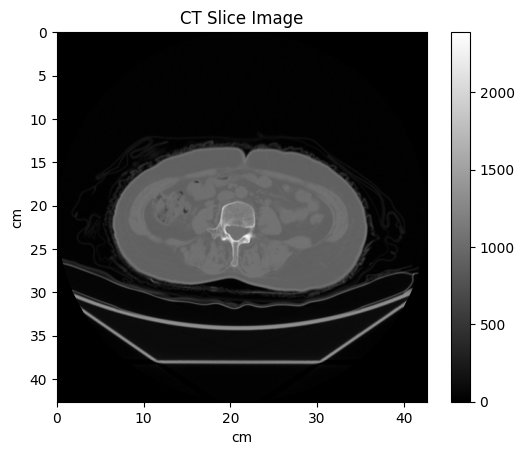

In [8]:
show_mr_image(task6_slices[0], task6_dicom_meta[0]['pixel_spacing'][0], r=task6_slices.shape[1], c=task6_slices.shape[2])

## 1-2. plot the axial, sagittal, coronal image

In [9]:
# save the aspect ratio of each slice
task6_aspect = dict()
for i in range(len(task6_slices)):
    ps = task6_dicom_meta[i]['pixel_spacing']
    ss = task6_dicom_meta[i]['slice_thickness']
    ax_aspect = ps[1] / ps[0]
    sag_aspect = ps[1] / ss
    cor_aspect = ss / ps[0]
    task6_aspect[i] = {
        'ax_aspect': ax_aspect,
        'sag_aspect': sag_aspect,
        'cor_aspect': cor_aspect
    }


In [10]:
task6_aspect[0]

{'ax_aspect': 1.0, 'sag_aspect': 0.3328124, 'cor_aspect': 3.004695738500128}

In [11]:
task6_img3d = task6_slices.transpose(1, 2, 0)

In [12]:
task6_img3d.shape

(512, 512, 125)

In [13]:
task6_img3d[:,:,0]

array([[0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]], dtype=int16)

In [14]:
(task6_dicom_meta[0]['pixel_spacing'][0])

'0.832031'

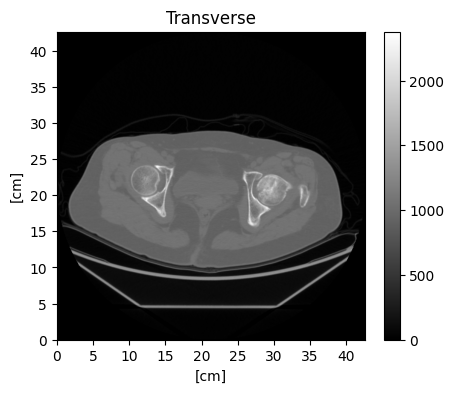

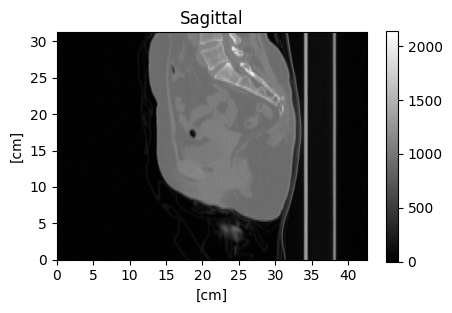

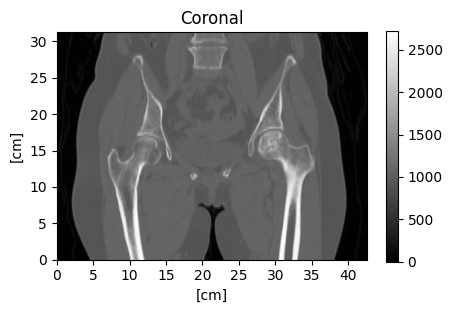

In [15]:
def show_transverse_image(img3d, loc, meta_data):
    pixcel_spacing = meta_data['pixel_spacing'][0] / 10
    r = img3d.shape[0]
    c = img3d.shape[1]
    plt.figure(figsize=(5, 4))
    plt.imshow(img3d[:, :, loc], cmap='gray', extent=[0, r*pixcel_spacing, 0, c*pixcel_spacing])
    # plt.imshow(img3d[:, :, loc], cmap='gray')
    plt.xticks(np.arange(0, r*pixcel_spacing, 5))
    plt.yticks(np.arange(0, c*pixcel_spacing, 5))
    plt.title('Transverse')
    plt.xlabel('[cm]')
    plt.ylabel('[cm]')
    plt.colorbar()
    plt.show()

def show_sagittal_image(img3d, loc, aspect, meta_data):
    pixcel_spacing = meta_data['pixel_spacing'][0] / 10
    height_spacing = meta_data['slice_thickness'] / 10
    r = img3d.shape[0]
    c = img3d.shape[2]
    plt.figure(figsize=(5, 3))
    plt.imshow(img3d[:, loc, :].T, cmap='gray', extent=[0, r*height_spacing, 0, c*pixcel_spacing], aspect=1/(aspect**2))
    plt.xticks(np.arange(0, r*height_spacing, 5*(1/aspect)), [f'{5*i}' for i in range(len(np.arange(0, r*height_spacing, 5*(1/aspect))))])
    plt.yticks(np.arange(0, c*pixcel_spacing, 5*aspect), [f'{5*i}' for i in range(len(np.arange(0, c*pixcel_spacing, 5*aspect)))])
    plt.title('Sagittal')
    plt.xlabel('[cm]')
    plt.ylabel('[cm]')
    plt.colorbar()
    plt.show()

def show_coronal_image(img3d, loc, aspect, meta_data):
    pixcel_spacing = meta_data['pixel_spacing'][0] / 10
    height_spacing = meta_data['slice_thickness'] / 10
    r = img3d.shape[2]
    c = img3d.shape[1]
    plt.figure(figsize=(5, 3))
    plt.imshow(img3d[loc, :, :].T, cmap='gray', extent=[0, c*pixcel_spacing, 0, r*height_spacing])
    plt.xticks(np.arange(0, c*pixcel_spacing, 5))
    plt.yticks(np.arange(0, r*height_spacing, 5))
    plt.title('Coronal')
    plt.xlabel('[cm]')
    plt.ylabel('[cm]')
    plt.colorbar()
    plt.show()

loc_tr = task6_img3d.shape[2] // 2    # axial range 0-125
loc_sag = task6_img3d.shape[1] // 2   # sagittal range 0-511
loc_cor = task6_img3d.shape[0] // 2   # coronal range 0-511

show_transverse_image(task6_img3d, loc_tr, task6_dicom_meta[0])
show_sagittal_image(task6_img3d, loc_sag, task6_aspect[0]['sag_aspect'], task6_dicom_meta[0])
show_coronal_image(task6_img3d, loc_cor, task6_aspect[0]['cor_aspect'], task6_dicom_meta[0])

## 2. segmentation bone

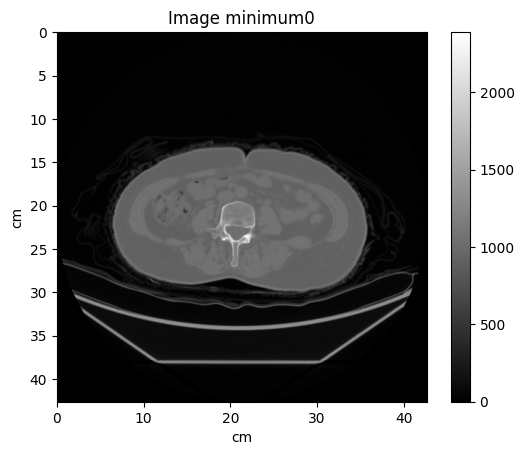

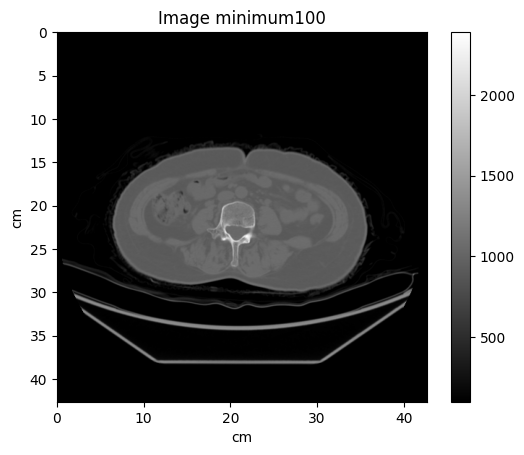

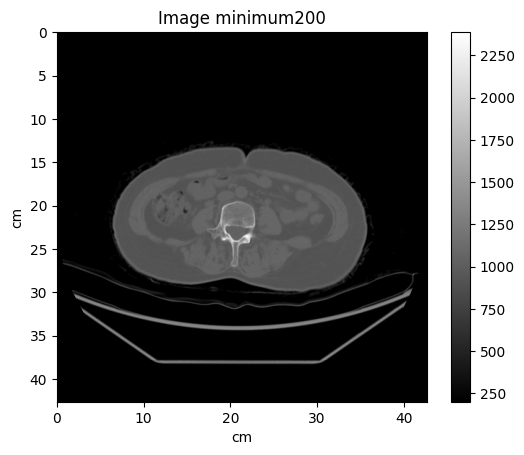

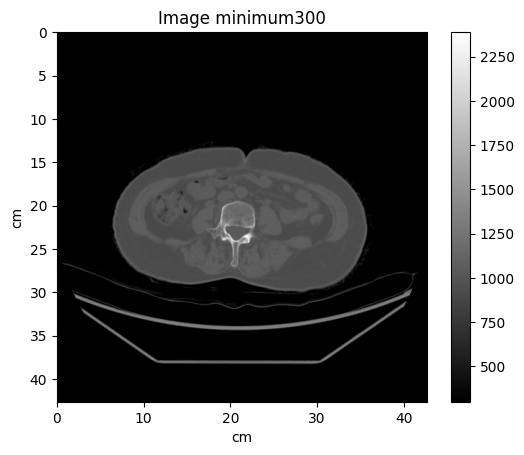

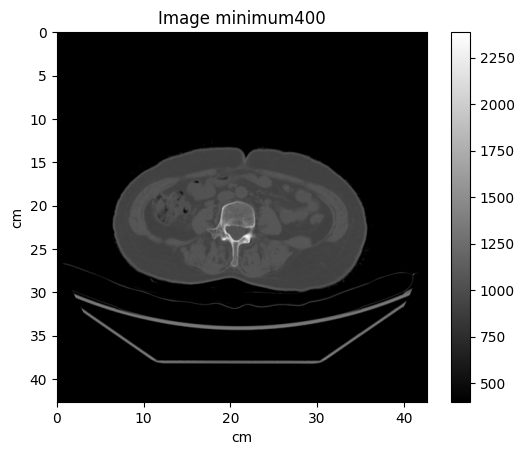

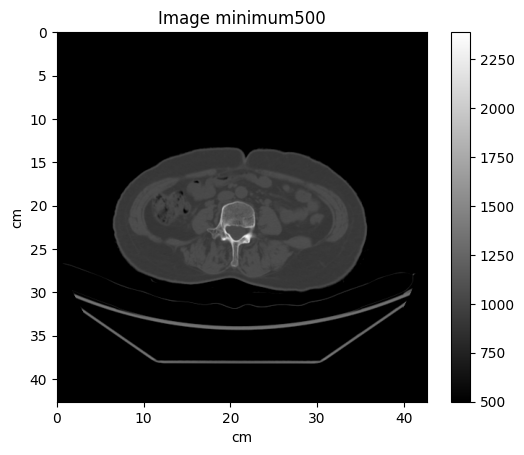

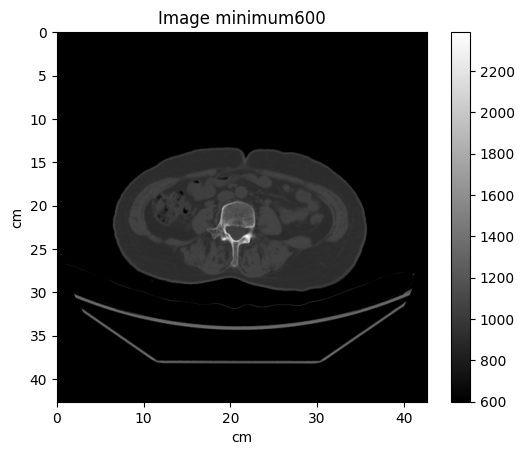

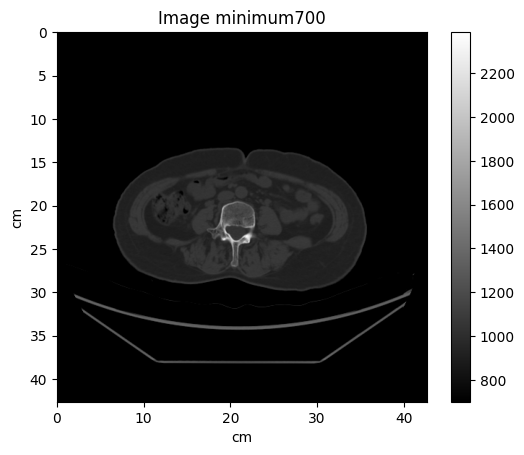

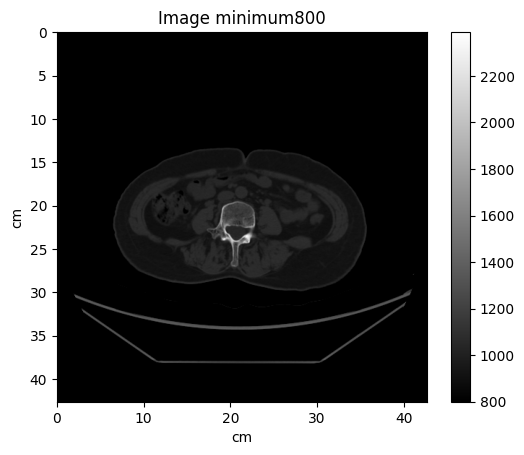

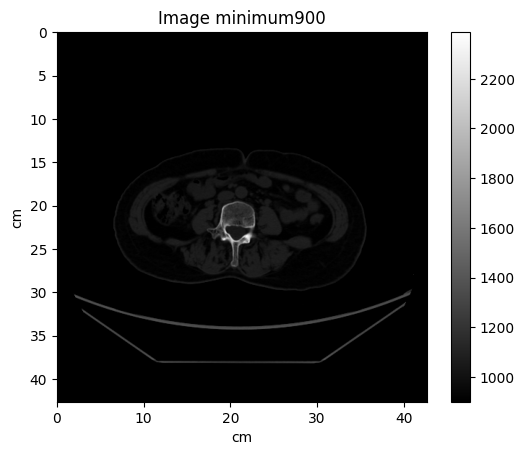

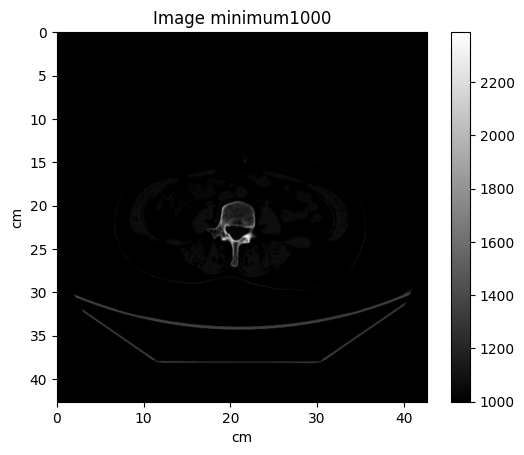

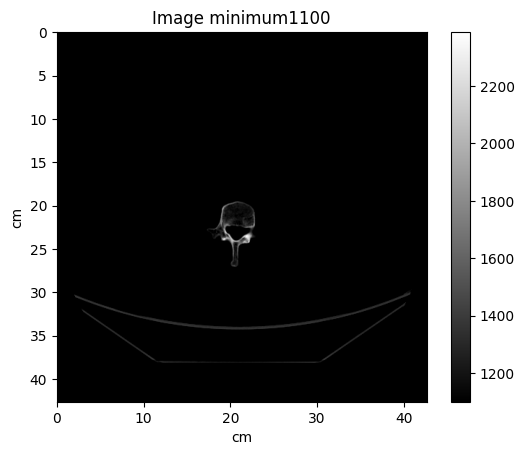

In [16]:
test = task6_img3d[:, :, 0]
for i in range(0, 1101, 100):
    test = np.maximum(i, test)
    show_mr_image(test, task6_dicom_meta[0]['pixel_spacing'][0], r=test.shape[0], c=test.shape[1], title=f'Image minimum{i}')


(array([[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]], dtype=int16),
 <matplotlib.image.AxesImage at 0x13020d280>)

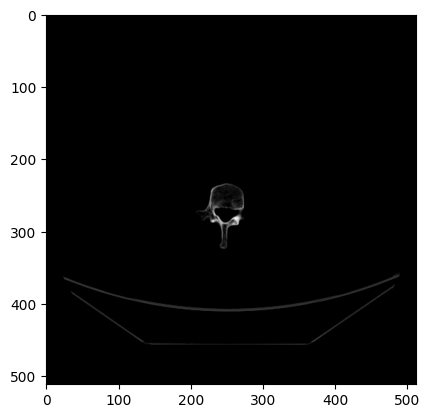

In [17]:
test = test - np.min(test)
test, plt.imshow(test, cmap='gray')

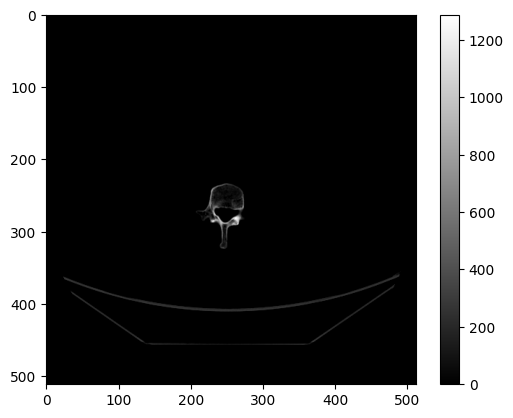

In [18]:
bone_filter = np.ones_like(test)
test = test * bone_filter
plt.imshow((test), cmap='gray')
plt.colorbar()
plt.show()

In [19]:
def fill_mean(img):
    for r in range(1, img.shape[0]-1):
        for c in range(1,img.shape[1]-1):
            if img[r, c] == 0:
                img[r, c] = (img[r-1, c-1] + img[r-1, c] + img[r-1, c+1] + img[r, c-1] + img[r, c+1] + img[r+1, c-1] + img[r+1, c] + img[r+1, c+1]) / 8
    return img

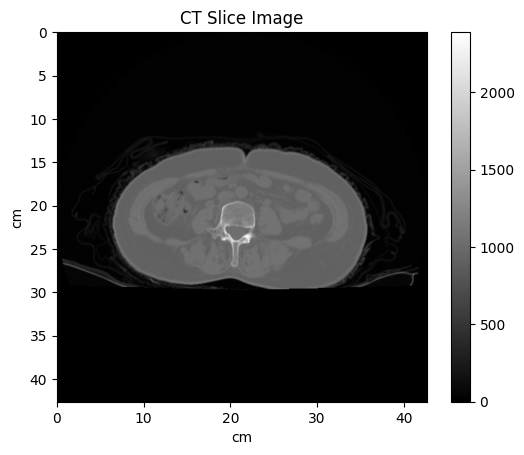

In [20]:
def remove_plate(img3d):
    remove_filter = np.ones_like(img3d[:,:,0])
    height = 350
    for l in range(img3d.shape[2]):
        for c in range(256):
            remove_filter[height:, c] = 0
            if c % 40 == 0:
                height += 1
        for c in range(256, 512):
            remove_filter[height:, c] = 0
            if c % 40 == 0:
                height -= 1
    remove_filter = np.array([remove_filter for _ in range(img3d.shape[2])])
    remove_filter = remove_filter.transpose(1, 2, 0)
    return img3d * remove_filter
rm_plate_test = remove_plate(task6_img3d)
show_mr_image(rm_plate_test[:,:,0], task6_dicom_meta[0]['pixel_spacing'][0], r=task6_img3d.shape[0], c=task6_img3d.shape[1])

In [21]:
def bone_filtering(img3d):
    segmented_img = list()
    img3d = remove_plate(img3d)
    for i in range(img3d.shape[2]):
        img = img3d[:,:,i]
        img = np.maximum(1100, img)
        img = img - np.min(img)
        bone_filter = np.ones_like(img)
        img = img * bone_filter
        img = fill_mean(img)
        segmented_img.append(img)
    segmented_img = np.array(segmented_img)
    segmented_img = segmented_img.transpose(1, 2, 0)
    return segmented_img

In [22]:
segmented_bone_3d_img = bone_filtering(task6_img3d)

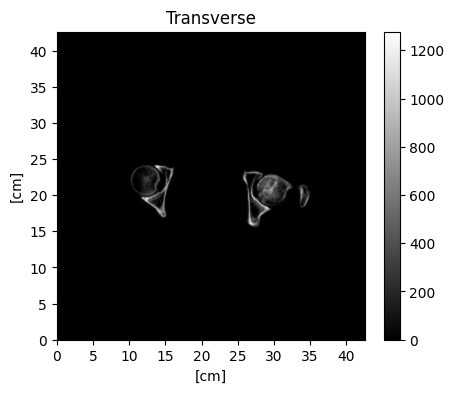

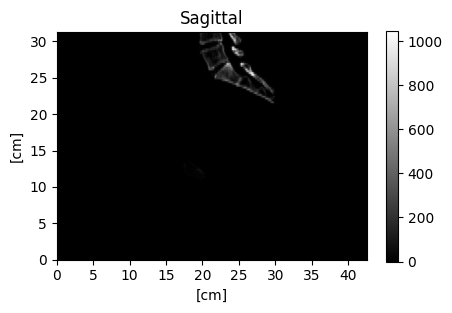

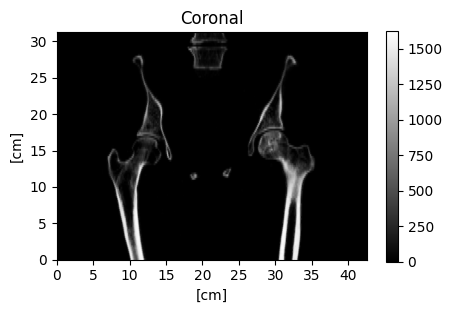

In [23]:
show_transverse_image(segmented_bone_3d_img, loc_tr, task6_dicom_meta[0])
show_sagittal_image(segmented_bone_3d_img, loc_sag, task6_aspect[0]['sag_aspect'], task6_dicom_meta[0])
show_coronal_image(segmented_bone_3d_img, loc_cor, task6_aspect[0]['cor_aspect'], task6_dicom_meta[0])

## 3. extract edges using 2D wavelet

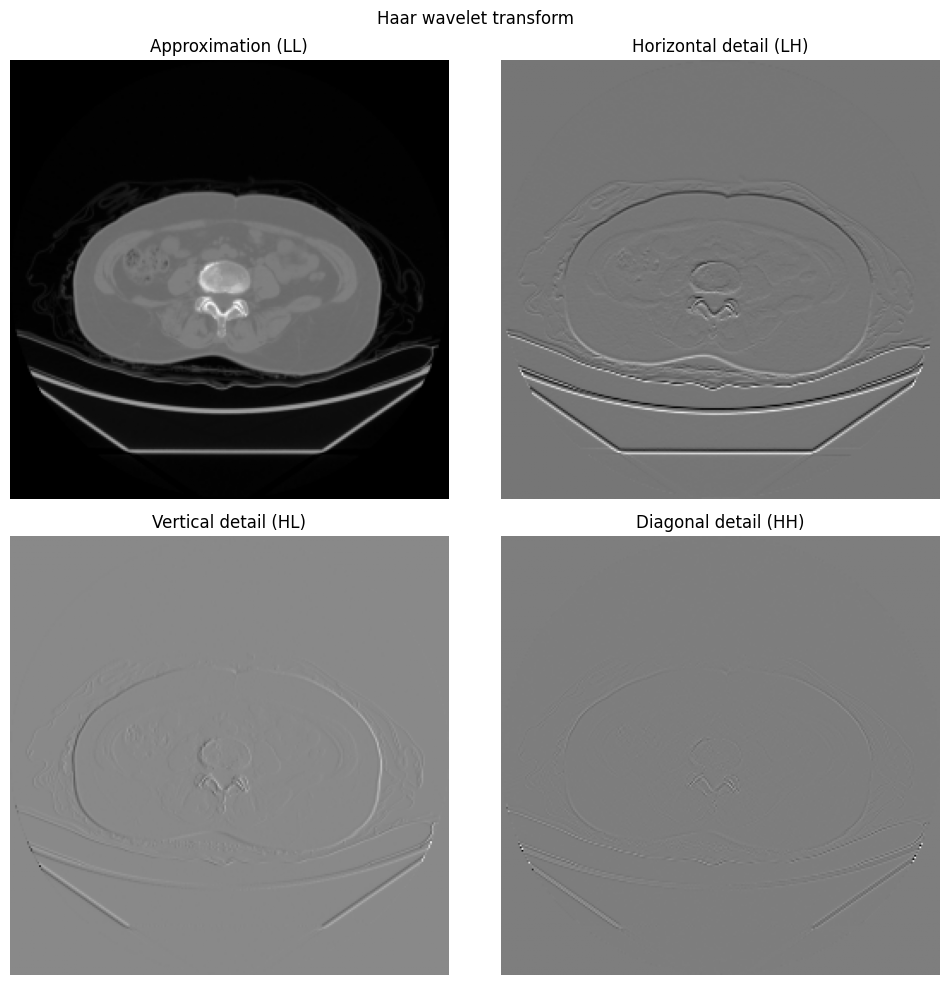

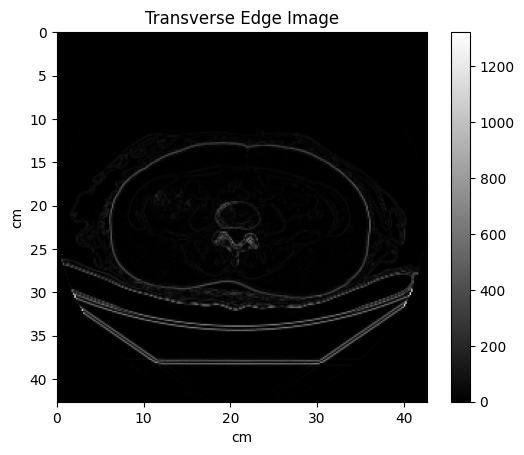

In [24]:
import pywt

img = task6_img3d[:,:,4]
# img = segmented_bone_3d_img[:,:,9]
coeffs2 = pywt.dwt2(img, 'haar')
LL, (LH, HL, HH) = coeffs2

pixcel_spacing = task6_dicom_meta[0]['pixel_spacing'][0] / 10
height_spacing = task6_dicom_meta[0]['slice_thickness'] / 10
r = segmented_bone_3d_img.shape[0]
c = segmented_bone_3d_img.shape[1]

fig, ax = plt.subplots(2, 2, figsize=(10, 10))
fig.suptitle('Haar wavelet transform')
ax[0, 0].imshow(LL, cmap='gray', extent=[0, r*pixcel_spacing, 0, c*pixcel_spacing])
ax[0, 0].axis('off')
ax[0, 0].set_title('Approximation (LL)')
ax[0, 1].imshow(LH, cmap='gray', extent=[0, r*pixcel_spacing, 0, c*pixcel_spacing])
ax[0, 1].axis('off')
ax[0, 1].set_title('Horizontal detail (LH)')
ax[1, 0].imshow(HL, cmap='gray', extent=[0, r*pixcel_spacing, 0, c*pixcel_spacing])
ax[1, 0].axis('off')
ax[1, 0].set_title('Vertical detail (HL)')
ax[1, 1].imshow(HH, cmap='gray', extent=[0, r*pixcel_spacing, 0, c*pixcel_spacing])
ax[1, 1].axis('off')
ax[1, 1].set_title('Diagonal detail (HH)')
fig.tight_layout()
plt.show()

edge_img = np.sqrt((LH**2) + (HL**2) + HH**2)


show_mr_image(edge_img, task6_dicom_meta[0]['pixel_spacing'][0], r=segmented_bone_3d_img.shape[0], c=segmented_bone_3d_img.shape[1], title='Transverse Edge Image')

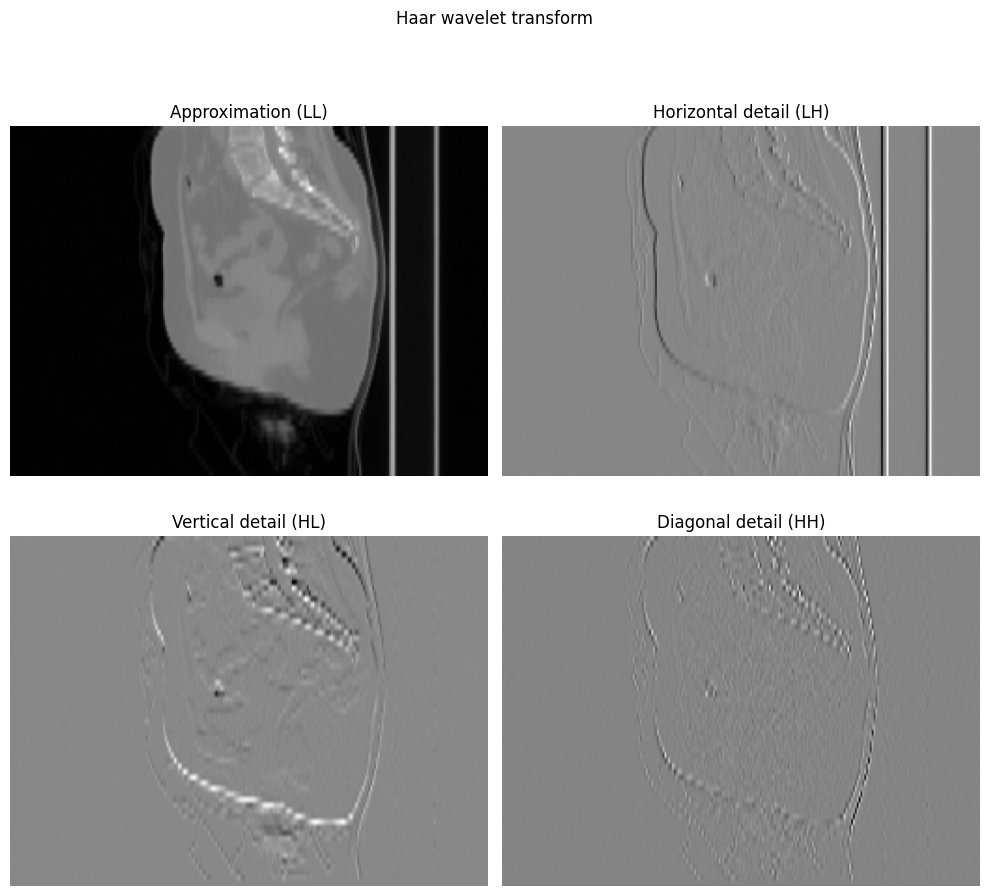

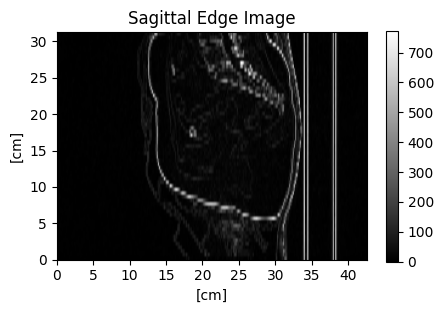

In [25]:
import pywt
# sagittal
img = task6_img3d[:, 256, :]
# img = segmented_bone_3d_img[:,240,:]
coeffs2 = pywt.dwt2(img, 'haar')
LL, (LH, HL, HH) = coeffs2

pixcel_spacing = task6_dicom_meta[0]['pixel_spacing'][0] / 10
height_spacing = task6_dicom_meta[0]['slice_thickness'] / 10
r = segmented_bone_3d_img.shape[0]
c = segmented_bone_3d_img.shape[2]
aspect = 1/(task6_aspect[0]['sag_aspect']**2)

fig, ax = plt.subplots(2, 2, figsize=(10, 10))
fig.suptitle('Haar wavelet transform')
ax[0, 0].imshow(LL.T, cmap='gray', extent=[0, r*height_spacing, 0, c*pixcel_spacing], aspect=aspect)
ax[0, 0].axis('off')
ax[0, 0].set_title('Approximation (LL)')
ax[0, 1].imshow(LH.T, cmap='gray', extent=[0, r*height_spacing, 0, c*pixcel_spacing], aspect=aspect)
ax[0, 1].axis('off')
ax[0, 1].set_title('Horizontal detail (LH)')
ax[1, 0].imshow(HL.T, cmap='gray', extent=[0, r*height_spacing, 0, c*pixcel_spacing], aspect=aspect)
ax[1, 0].axis('off')
ax[1, 0].set_title('Vertical detail (HL)')
ax[1, 1].imshow(HH.T, cmap='gray', extent=[0, r*height_spacing, 0, c*pixcel_spacing], aspect=aspect)
ax[1, 1].axis('off')
ax[1, 1].set_title('Diagonal detail (HH)')
fig.subplots_adjust(top=1.02)
fig.tight_layout()
plt.show()

edge_img = np.sqrt(LH**2 + HL**2 + HH**2)
aspect = task6_aspect[0]['sag_aspect']

plt.figure(figsize=(5, 3))
plt.imshow(edge_img.T, cmap='gray', extent=[0, r*height_spacing, 0, c*pixcel_spacing], aspect=1/(aspect**2))
plt.xticks(np.arange(0, r*height_spacing, 5*(1/aspect)), [f'{5*i}' for i in range(len(np.arange(0, r*height_spacing, 5*(1/aspect))))])
plt.yticks(np.arange(0, c*pixcel_spacing, 5*aspect), [f'{5*i}' for i in range(len(np.arange(0, c*pixcel_spacing, 5*aspect)))])
plt.title('Sagittal Edge Image')
plt.xlabel('[cm]')
plt.ylabel('[cm]')
plt.colorbar()
plt.show()

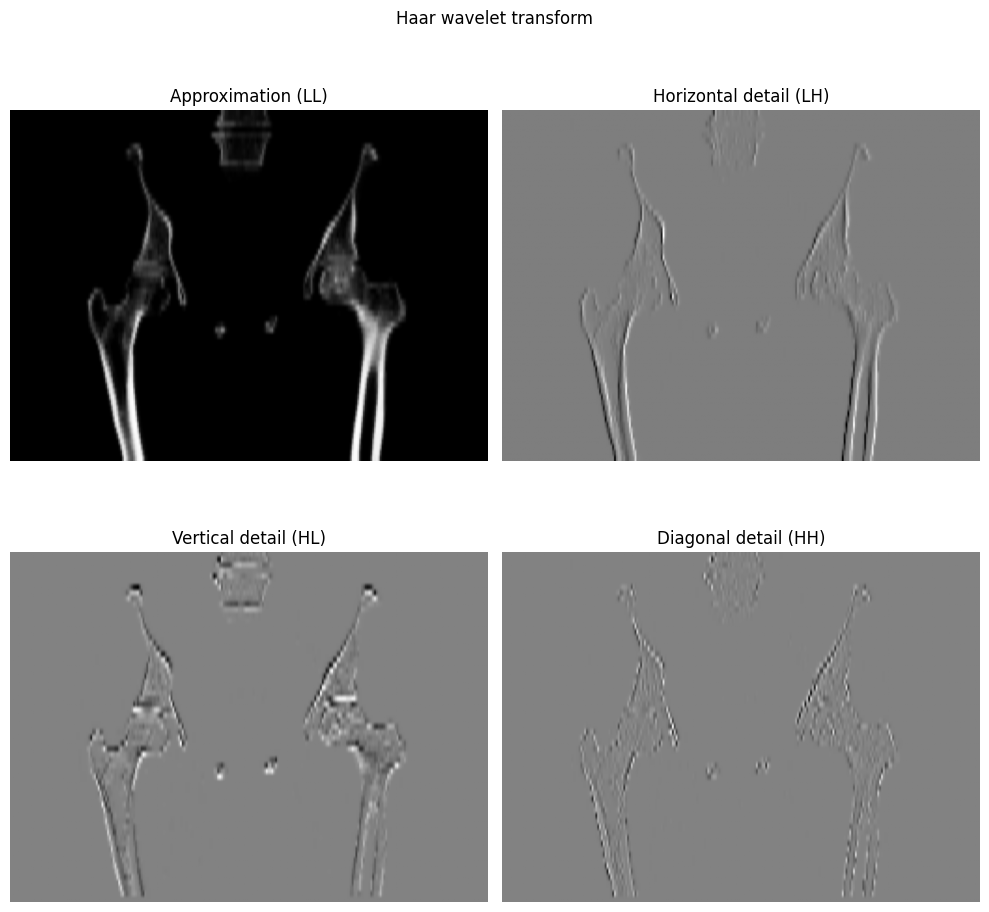

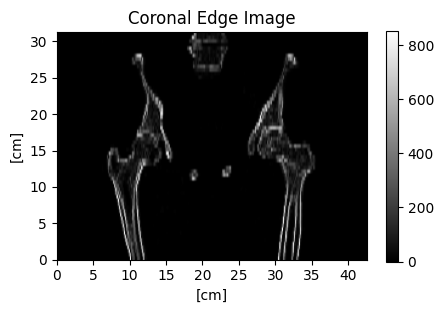

In [26]:
# coronal
img = segmented_bone_3d_img[256,:,:]
coeffs2 = pywt.dwt2(img, 'haar')
LL, (LH, HL, HH) = coeffs2

pixcel_spacing = task6_dicom_meta[0]['pixel_spacing'][0] / 10
height_spacing = task6_dicom_meta[0]['slice_thickness'] / 10
r = segmented_bone_3d_img.shape[2]
c = segmented_bone_3d_img.shape[1]

fig, ax = plt.subplots(2, 2, figsize=(10, 10))
fig.suptitle('Haar wavelet transform')
ax[0, 0].imshow(LL.T, cmap='gray', extent=[0, c*pixcel_spacing, 0, r*height_spacing])
ax[0, 0].axis('off')
ax[0, 0].set_title('Approximation (LL)')
ax[0, 1].imshow(LH.T, cmap='gray', extent=[0, c*pixcel_spacing, 0, r*height_spacing])
ax[0, 1].axis('off')
ax[0, 1].set_title('Horizontal detail (LH)')
ax[1, 0].imshow(HL.T, cmap='gray', extent=[0, c*pixcel_spacing, 0, r*height_spacing])
ax[1, 0].axis('off')
ax[1, 0].set_title('Vertical detail (HL)')
ax[1, 1].imshow(HH.T, cmap='gray', extent=[0, c*pixcel_spacing, 0, r*height_spacing])
ax[1, 1].axis('off')
ax[1, 1].set_title('Diagonal detail (HH)')
fig.tight_layout()
plt.show()

edge_img = np.sqrt(LH**2 + HL**2 + HH**2)
plt.figure(figsize=(5, 3))
plt.imshow(edge_img.T, cmap='gray', extent=[0, c*pixcel_spacing, 0, r*height_spacing])
plt.xticks(np.arange(0, c*pixcel_spacing, 5))
plt.yticks(np.arange(0, r*height_spacing, 5))
plt.title('Coronal Edge Image')
plt.xlabel('[cm]')
plt.ylabel('[cm]')
plt.colorbar()
plt.show()


### YoLo

In [30]:
pip install pydicom

Note: you may need to restart the kernel to use updated packages.


In [32]:
import os
import pydicom
import numpy as np

# 로컬 DICOM 폴더 경로 설정
dicom_path = '/Users/g.j.kim/Downloads/Task6Data/blind'

# DICOM 파일 로딩
task6_dicom_files = {}
for fname in os.listdir(dicom_path):
    if fname.endswith('.dcm'):
        filepath = os.path.join(dicom_path, fname)
        ds = pydicom.dcmread(filepath)
        slice_idx = int(os.path.splitext(fname)[0])
        task6_dicom_files[slice_idx] = ds

# 메타데이터 및 픽셀 배열 추출
task6_dicom_meta = {}
task6_slices = {}
for key, file in task6_dicom_files.items():
    task6_dicom_meta[key] = {
        'pixel_spacing': file.PixelSpacing,
        'slice_thickness': file.SliceThickness,
        'spacing_location': file.SliceLocation
    }
    task6_slices[key] = file.pixel_array

# 3D CT 이미지 생성
temp = [np.maximum(0, task6_slices[i]) for i in sorted(task6_slices)]
task6_img3d = np.array(temp).transpose(1, 2, 0)

In [33]:
import matplotlib.pyplot as plt

# 저장 경로 설정
save_dir_train = '/Users/g.j.kim/Downloads/Task6Data/yolo_dataset/images/train'
save_dir_val = '/Users/g.j.kim/Downloads/Task6Data/yolo_dataset/images/val'
os.makedirs(save_dir_train, exist_ok=True)
os.makedirs(save_dir_val, exist_ok=True)

# 학습용 80%, 검증용 20%로 나눔
num_slices = task6_img3d.shape[2]
split_idx = int(num_slices * 0.8)

# 이미지 저장
for i in range(num_slices):
    img = task6_img3d[:, :, i]
    fname = f"slice_{i:03d}.png"
    if i < split_idx:
        plt.imsave(os.path.join(save_dir_train, fname), img, cmap='gray')
    else:
        plt.imsave(os.path.join(save_dir_val, fname), img, cmap='gray')

In [34]:
import matplotlib.pyplot as plt

# 저장 경로 설정
save_dir_train = '/Users/g.j.kim/Downloads/Task6Data/yolo_dataset/images/train'
save_dir_val = '/Users/g.j.kim/Downloads/Task6Data/yolo_dataset/images/val'
os.makedirs(save_dir_train, exist_ok=True)
os.makedirs(save_dir_val, exist_ok=True)

# 학습용 80%, 검증용 20%로 나눔
num_slices = task6_img3d.shape[2]
split_idx = int(num_slices * 0.8)

# 이미지 저장
for i in range(num_slices):
    img = task6_img3d[:, :, i]
    fname = f"slice_{i:03d}.png"
    if i < split_idx:
        plt.imsave(os.path.join(save_dir_train, fname), img, cmap='gray')
    else:
        plt.imsave(os.path.join(save_dir_val, fname), img, cmap='gray')

In [35]:
yaml_content = """
train: /Users/g.j.kim/Downloads/Task6Data/yolo_dataset/images/train
val: /Users/g.j.kim/Downloads/Task6Data/yolo_dataset/images/val

nc: 1  # 클래스 수
names: ['bone']  # 클래스 이름
"""

with open('/Users/g.j.kim/Downloads/Task6Data/yolo_dataset/data.yaml', 'w') as f:
    f.write(yaml_content.strip())

In [ ]:
train: /Users/g.j.kim/Downloads/Task6Data/yolo_dataset/images/train
val: /Users/g.j.kim/Downloads/Task6Data/yolo_dataset/images/val

nc: 1
names: ['bone']

In [36]:
import os
import random

# 이미지 경로 (수정 필요할 수 있음)
img_dir = "/Users/g.j.kim/Downloads/Task6Data/yolo_dataset/images/train"
label_dir = "/Users/g.j.kim/Downloads/Task6Data/yolo_dataset/labels/train"
os.makedirs(label_dir, exist_ok=True)

# 이미지 리스트
img_list = [f for f in os.listdir(img_dir) if f.endswith('.png')]

# 임의로 중심 기준 박스 생성
for img_name in img_list:
    base = os.path.splitext(img_name)[0]
    label_path = os.path.join(label_dir, base + '.txt')
    
    # 중심 좌표 및 정규화된 너비/높이
    x_center, y_center = 0.5, 0.5
    width, height = 0.4, 0.4  # 예시로 전체 이미지의 40%
    
    with open(label_path, 'w') as f:
        f.write(f"0 {x_center} {y_center} {width} {height}\n")

In [37]:
import os

# val 이미지 경로 및 라벨 저장 경로
img_dir = "/Users/g.j.kim/Downloads/Task6Data/yolo_dataset/images/val"
label_dir = "/Users/g.j.kim/Downloads/Task6Data/yolo_dataset/labels/val"
os.makedirs(label_dir, exist_ok=True)

# 이미지 리스트 필터링
img_list = [f for f in os.listdir(img_dir) if f.endswith('.png')]

# 중심 정사각형 박스 생성 (클래스: 0)
for img_name in img_list:
    base = os.path.splitext(img_name)[0]
    label_path = os.path.join(label_dir, base + '.txt')
    
    # 중심 좌표 및 정규화된 너비/높이 (YOLO 포맷 기준)
    x_center, y_center = 0.5, 0.5
    width, height = 0.4, 0.4  # 예시 박스 크기

    with open(label_path, 'w') as f:
        f.write(f"0 {x_center} {y_center} {width} {height}\n")

In [40]:
import os

task6_root = "/Users/g.j.kim/Downloads/Task6Data"
print("📁 Contents of Task6Data:")
print(os.listdir(task6_root))

📁 Contents of Task6Data:
['blind', '.DS_Store', 'haar wavelet transform.png', 'yolov5', 'yolo_dataset']


In [41]:
import os

yolo_root = "/Users/g.j.kim/Downloads/Task6Data/yolov5"
for root, dirs, files in os.walk(yolo_root):
    print(f"\n📂 Directory: {root}")
    for d in dirs:
        print(f"  - {d}")


📂 Directory: /Users/g.j.kim/Downloads/Task6Data/yolov5
  - classify
  - segment
  - utils
  - models
  - __pycache__
  - yolo_dataset
  - bone_project
  - .github
  - .git
  - data

📂 Directory: /Users/g.j.kim/Downloads/Task6Data/yolov5/classify

📂 Directory: /Users/g.j.kim/Downloads/Task6Data/yolov5/segment

📂 Directory: /Users/g.j.kim/Downloads/Task6Data/yolov5/utils
  - docker
  - loggers
  - google_app_engine
  - segment
  - __pycache__
  - aws
  - flask_rest_api

📂 Directory: /Users/g.j.kim/Downloads/Task6Data/yolov5/utils/docker

📂 Directory: /Users/g.j.kim/Downloads/Task6Data/yolov5/utils/loggers
  - __pycache__
  - comet
  - clearml
  - wandb

📂 Directory: /Users/g.j.kim/Downloads/Task6Data/yolov5/utils/loggers/__pycache__

📂 Directory: /Users/g.j.kim/Downloads/Task6Data/yolov5/utils/loggers/comet
  - __pycache__

📂 Directory: /Users/g.j.kim/Downloads/Task6Data/yolov5/utils/loggers/comet/__pycache__

📂 Directory: /Users/g.j.kim/Downloads/Task6Data/yolov5/utils/loggers/clearml


In [42]:
import os
val_dir = "/Users/g.j.kim/Downloads/Task6Data/yolo_dataset/images/val"
print("파일 목록:", os.listdir(val_dir))


파일 목록: ['slice_116.png', 'slice_102.png', 'slice_103.png', 'slice_117.png', 'slice_101.png', 'slice_115.png', 'slice_114.png', 'slice_100.png', 'slice_104.png', 'slice_110.png', 'slice_111.png', 'slice_105.png', 'slice_113.png', 'slice_107.png', 'slice_106.png', 'slice_112.png', 'slice_123.png', 'slice_122.png', 'slice_120.png', 'slice_108.png', 'slice_109.png', 'slice_121.png', 'slice_119.png', 'slice_124.png', 'slice_118.png']
